# NAME

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from tqdm import tqdm
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Paso 1: Recopilación de datos y definición del problema

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

> A partir de las variables clínicas, predecir si el paciente es diabético (sí/no). Nuestro variable objetivo (y) es `Outcome`. 

In [3]:
df = pd.read_csv('../data/raw/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


- `Pregnancies` Número de embarazos del paciente (numérico)
- `Glucose` Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- `BloodPressure` Presión arterial diastólica (medida en mm Hg) (numérico)
- `SkinThickness` Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- `Insulin` Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
- `BMI` Índice de masa corporal (numérico)
- `DiabetesPedigreeFunction` Función de pedigrí de diabetes (numérico)
- `Age` Edad del paciente (numérico)
- `Outcome` Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


> ### Observaciones:
>
> - Existen un total de 768 filas y 9 columnas.
> - Ninguna de las variables contiene valores nulos.
> - Los datos incluyen 9 características numéricas y no tiene ninguna característica categórica.

## Paso 2: EDA completo

### Limpieza de datos: Eliminar duplicados

In [7]:
df_original = df.copy()
df_original

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

>  ### Observaciones
>
> No encontramos ninguna fila duplicada. 

### Limpieza de datos: Eliminar información irrelevante

> ### Observaciones:
>
> Teniendo pocos datos, por ahora hemos decidido mantener todas las variables, porque todas parecen ser relevantes.

### Análisis de Variables

#### Análisis de Variables Univariante Numéricas 

Las variables numéricas son: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age` y `Outcome`.

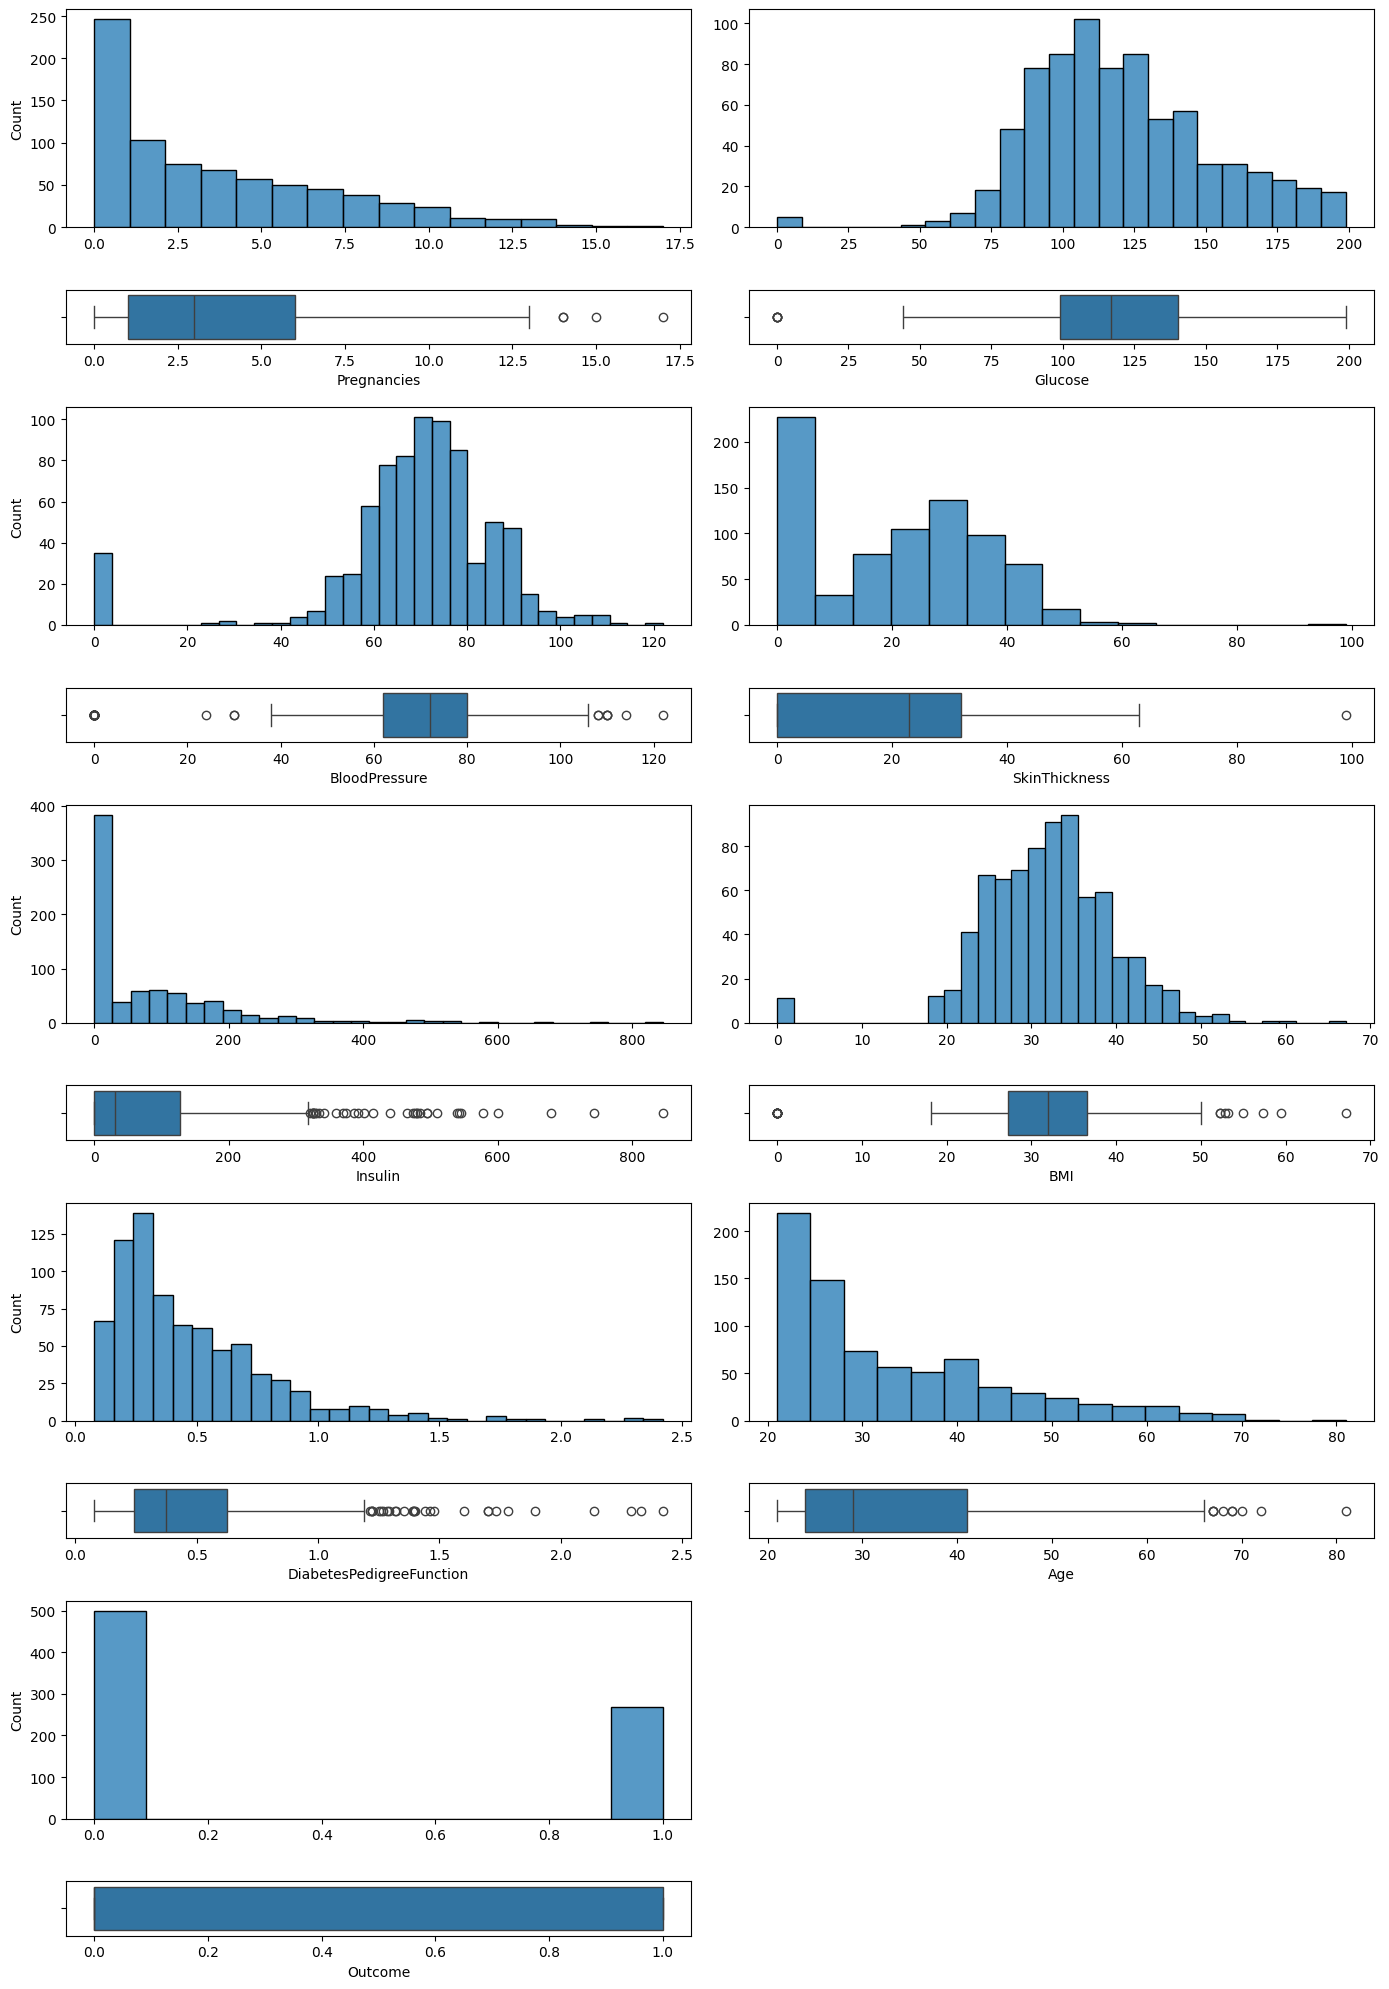

In [25]:
fig, axis = plt.subplots(10, 2, figsize=(14, 20), gridspec_kw={'height_ratios': [4, 1, 4, 1, 4, 1, 4, 1, 4, 1]})

# Creating a multiple figure with histograms and box plots
sns.histplot(ax=axis[0, 0], data=df, x='Pregnancies').set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x='Pregnancies')
sns.histplot(ax=axis[0, 1], data=df, x='Glucose').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x='Glucose')
sns.histplot(ax=axis[2, 0], data=df, x='BloodPressure').set(xlabel=None)
sns.boxplot(ax=axis[3, 0], data=df, x='BloodPressure')
sns.histplot(ax=axis[2, 1], data=df, x='SkinThickness').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df, x='SkinThickness')
sns.histplot(ax=axis[4, 0], data=df, x='Insulin').set(xlabel=None)
sns.boxplot(ax=axis[5, 0], data=df, x='Insulin')
sns.histplot(ax=axis[4, 1], data=df, x='BMI').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[5, 1], data=df, x='BMI')
sns.histplot(ax=axis[6, 0], data=df, x='DiabetesPedigreeFunction').set(xlabel=None)
sns.boxplot(ax=axis[7, 0], data=df, x='DiabetesPedigreeFunction')
sns.histplot(ax=axis[6, 1], data=df, x='Age').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[7, 1], data=df, x='Age')
sns.histplot(ax=axis[8, 0], data=df, x='Outcome').set(xlabel=None)
sns.boxplot(ax=axis[9, 0], data=df, x='Outcome')

# Remove an axis (subplot) from the figure
fig.delaxes(axis[8,1])
fig.delaxes(axis[9,1])

# Adjust the layout
plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - **Pregnancies**: La mayor parte de las mujeres del dataset no ha tenido muchos embarazos (casi todas las barras altas están entre 0 y 3 embarazos).
> - **Glucose**: Distribución unimodal, con la mayoría de valores entre ~80 y 180 mg/dL, pico alrededor de 100–130 mg/dL, rango típico en un test de tolerancia. Existen algunos valores extremadamente bajos (casi 0) que, clínicamente, no pueden ser reales. 
> - **BloodPressure**: Hay valores cercanos a 0 mmHg, imposibles en un paciente vivo. Los valores se concentran en torno a 70–80 mmHg.
> - **SkinThickness**: Se observan muchísimos valores 0.
> - **Insulin**: Gran pico en 0: muchísimos pacientes tienen valor 0, lo que no es fisiológico. 
> - **BMI**: Distribución aproximadamente normal/unimodal, centrada en torno a 30 kg/m².
> - **DiabetesPedigreeFunction**: Distribución claramente asimétrica a la derecha: la mayoría de los valores se concentran entre 0.1 y 0.6.
> - **Age**: Histograma con bastantes pacientes entre 20 y 40 años, y una cola hacia edades mayores; pocos pacientes >60–70 años.
Varias variables (como Glucose, BloodPressure, SkinThickness) tienen ceros que representan valores faltantes, no mediciones reales.

#### Análisis numérico (completo)

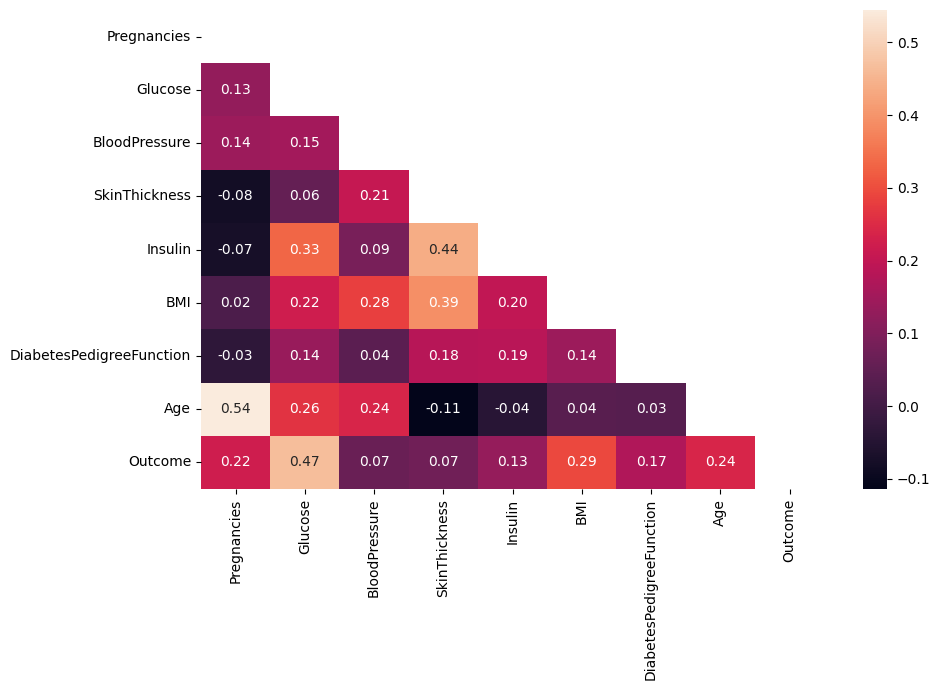

In [26]:
corr = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

> ##### Observaciones:
>
> - **Glucose – Outcome: 0.47** Es la correlación más alta con el resultado de diabetes. A mayor nivel de glucosa, mayor probabilidad de ser diabético.
> - **BMI – Outcome: 0.29** Correlación positiva moderada, valores más altos de IMC (sobrepeso) se asocian con mayor presencia de diabetes.
> - **Age – Outcome: 0.24** Correlación positiva débil, las personas de mayor edad tienden a tener algo más de diabetes.
> - **Edad y embarazos: Age – Pregnancies: 0.54** Correlación medio alta, a mayor edad, más embarazos acumulados.
> - **Glucose – Insulin: 0.44** Personas con más glucosa tienden a tener niveles de insulina más altos.

#### Análisis de outliers

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


> Observaciones
>
> Varias columnas tienen un valor mínimo de 0 que parece no corresponder a datos reales, como ya hemos visto en el gráfico de correlación.

**Outliers: Visualización**

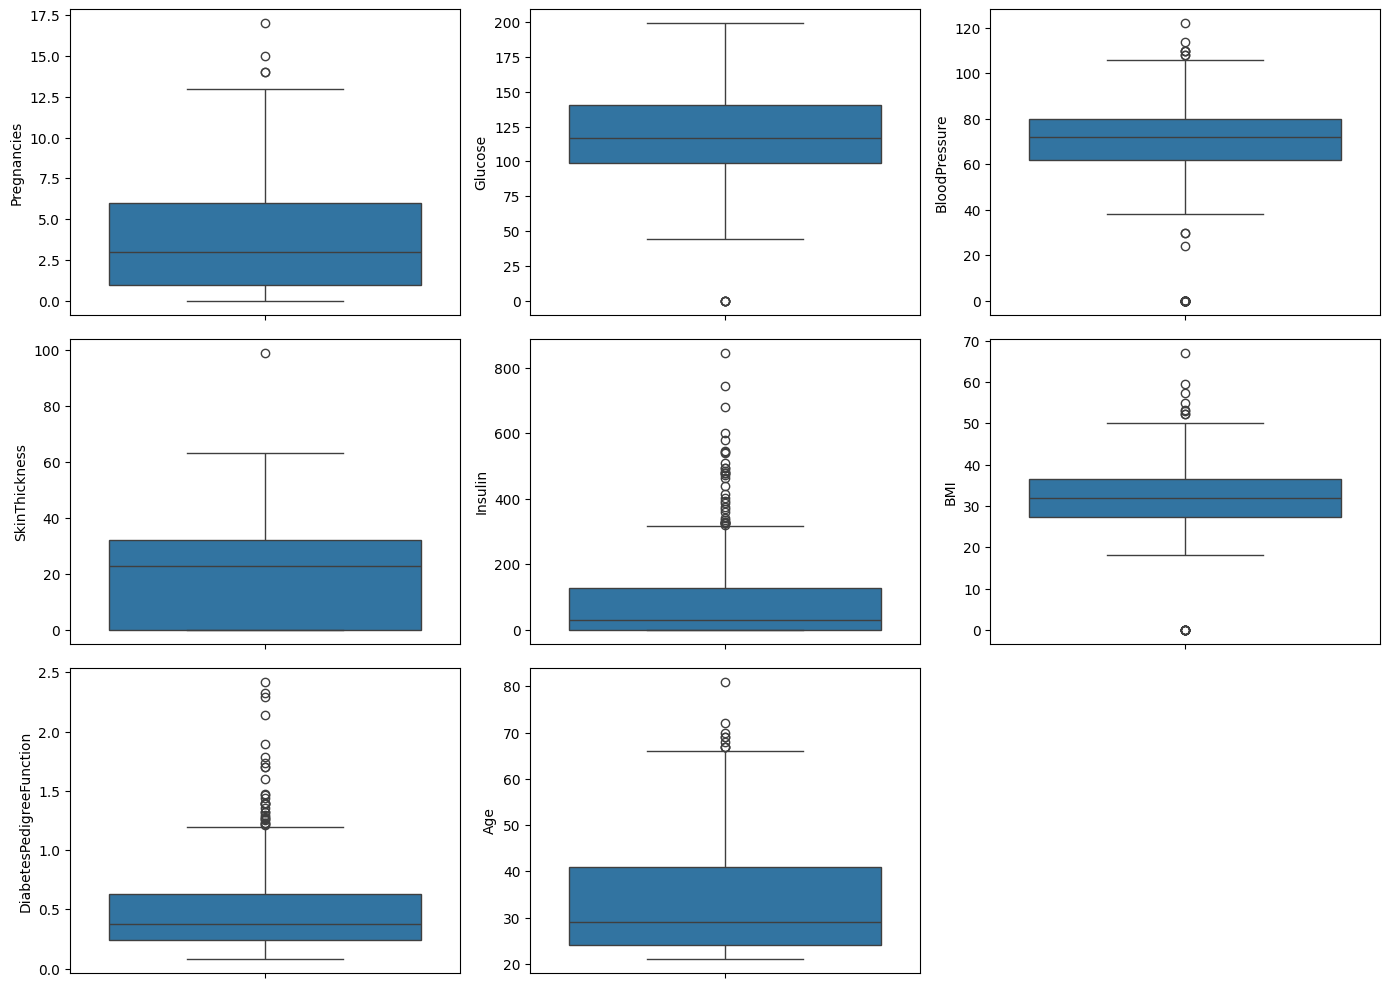

In [35]:
fig, axis = plt.subplots(3, 3, figsize=(14, 10))

sns.boxplot(ax=axis[0, 0], data=df, y='Pregnancies')
sns.boxplot(ax=axis[0, 1], data=df, y='Glucose')
sns.boxplot(ax=axis[0, 2], data=df, y='BloodPressure')
sns.boxplot(ax=axis[1, 0], data=df, y='SkinThickness')
sns.boxplot(ax=axis[1, 1], data=df, y='Insulin')
sns.boxplot(ax=axis[1, 2], data=df, y='BMI')
sns.boxplot(ax=axis[2, 0], data=df, y='DiabetesPedigreeFunction')
sns.boxplot(ax=axis[2, 1], data=df, y='Age')

fig.delaxes(axis[2, 2])
plt.tight_layout()
plt.show()

> #### Observaciones
>
> Podemos determinar fácilmente que las variables afectadas por outliers son `Glucose`, `BloodPressure`, `DiabetesPedigreeFunction`, `SkinThickness`, `Insulin`, `BMI`. Deberíamos establecer límites superior e inferior para determinar si un punto de datos debe considerarse o no un valor atípico.